In [ ]:
import numpy as np

In [ ]:
import gpjax

c:\Users\ISaha\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print(gpjax.__version__)  # Should print 0.15.0

0.18.0


In [ ]:
import numpyro
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

import jax
jax.config.update("jax_enable_x64", True)
import scipy
from scipy.interpolate import interp1d

In [ ]:
import pandas as pd
#GRAVITY ANOMALY DATA
y=pd.read_csv(r"C:\Users\ISaha\Downloads\gravity_anomaly_Godavari.dat")
x=pd.read_csv(r"C:\Users\ISaha\Downloads\x_obs_Godavari.dat")
z=pd.read_csv(r"C:\Users\ISaha\Downloads\depth_Zhou2012_3a (1).dat")

In [ ]:
data=pd.concat([x,y,z],axis=1)
data.columns = ['X', 'g','BD']

In [ ]:
from typing import Dict
import jax.numpy as jnp
from functools import partial
from jax import jit
from gpjax.mean_functions import AbstractMeanFunction
from gpjax.kernels import AbstractKernel
#import jax
import jax.numpy as jnp
#import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from dataclasses import dataclass
from typing import Dict


In [ ]:
n= 37 #We are considering 37 prisms here
# Defining centre value of horizontal co-ordinate of each prism
co=np.arange(500,37500,1000)
# Defining width of each prism
wid=np.zeros(n)
for j in range(n):
    wid[j]= 1000 # in meter
#surface value in meter
td=np.zeros(n)
for j in range(n):
    td[j]= 10**-6 # in meter (taking MSL as our observing surface i.e no undulation)


#Creating x co-ordinate values for 1st layer for each prism
xs=np.zeros(n+1)
xs[0]=co[0]-(wid[0]*0.5)
xs[n]=co[n-1]+(wid[n-1]*0.5)
for i in range(1,n):
    xs[i]=co[i-1]+(0.5*wid[i-1])
X_test=np.linspace(0,37000,200)

#Creating z1 co-ordinate values for 1st layer for each prism
zs1=np.zeros(n+1)
#Creating surface points
zs0=np.zeros(n+1)
R0=np.zeros(((n+1),2))
for i in range(n+1):
    R0[i]=[xs[i],zs0[i]]

In [ ]:
X_f = interp1d(data['X'],data['BD'],'linear')
z_prev = X_f(co)
g_f = interp1d(data['X'],data['g'],'linear')
g = g_f(co)


In [ ]:
#First defining the function g_ano() replacing jnp in place of np in the g_anomaly() function.
from os import name
def g_ano(x,A,m,D,d,rho):
    G=6.67*(10**-6)
    r1=(((x-A)+(0.5*m))**2)+((d)**2)
    r2=(((x-A)+(0.5*m))**2)+((D)**2)
    r3=(((x-A)-(0.5*m))**2)+((d)**2)
    r4=(((x-A)-(0.5*m))**2)+((D)**2)
    f1=jnp.arctan((x-A+(0.5*m))/D)-jnp.arctan((x-A-(0.5*m))/D)
    f2=jnp.arctan((x-A+(0.5*m))/d)-jnp.arctan((x-A-(0.5*m))/d)
    f3=0.5*(x-A)*(jnp.log10((r2*r3)/(r1*r4)))
    f4=0.25*m*(jnp.log10((r2*r4)/(r1*r3)))
    f=(D*f1)-(d*f2)+f3+f4
    return 2*G*rho*f


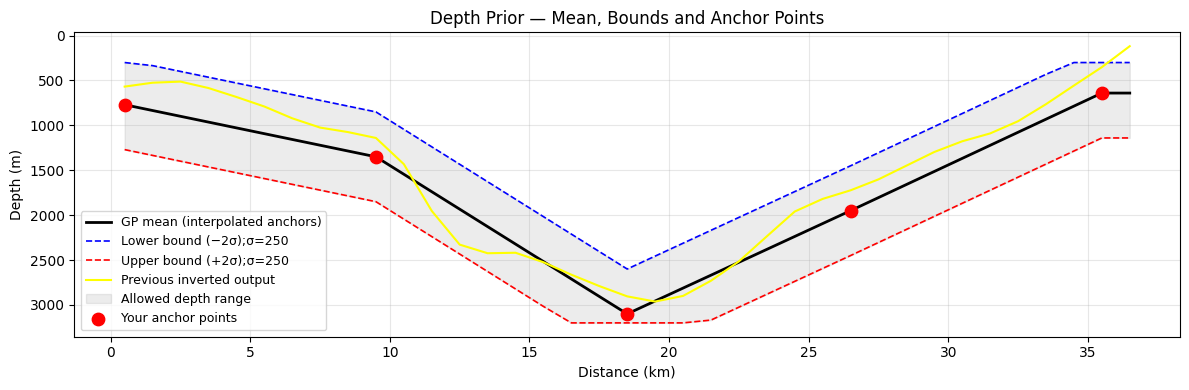

 Prism   Centre(m)    Mean depth    Lo bound    Hi bound
-------------------------------------------------------
     1         500         770.0       300.0      1270.0
     2        1500         834.4       334.4      1334.4
     3        2500         898.9       398.9      1398.9
     4        3500         963.3       463.3      1463.3
     5        4500        1027.8       527.8      1527.8
     6        5500        1092.2       592.2      1592.2
     7        6500        1156.7       656.7      1656.7
     8        7500        1221.1       721.1      1721.1
     9        8500        1285.6       785.6      1785.6
    10        9500        1350.0       850.0      1850.0
    11       10500        1544.4      1044.4      2044.4
    12       11500        1738.9      1238.9      2238.9
    13       12500        1933.3      1433.3      2433.3
    14       13500        2127.8      1627.8      2627.8
    15       14500        2322.2      1822.2      2822.2
    16       15500        2516.7

In [ ]:
import numpy as np
from scipy.linalg import cholesky as scipy_cholesky

# ── Prism centres ─────────────────────────────────────────────────
n  = 37
co = np.arange(500, 37500, 1000)   # shape (37,)

# ═════════════════════════════════════════════════════════════════
# USER INPUTS — edit these
# ═════════════════════════════════════════════════════════════════

# 1. Anchor points — your geological expectation at key locations
#    Add / remove rows as needed
anchor_x     = np.array([500, 9500, 18500, 26500, 35500])  # metres along profile
anchor_depth = np.array([770,1350, 3100,1950, 640])  # expected depth (metres)

# 2. Smoothness — how gradually depth changes between prisms
#    Large (e.g. 8000) → very smooth basin
#    Small (e.g. 2000) → sharp, faulted edges
length_scale = 8000.0   # metres

# 3. Variability — how far depth can stray from your anchor expectation
#    This sets the ± spread around the mean profile
sigma_depth  = 250.0    # metres  (1-sigma)

# 4. Hard geological bounds — depth NEVER goes outside these
depth_global_min = 300.0
depth_global_max = 3200.0

# ═════════════════════════════════════════════════════════════════
# INTERPOLATION — GP mean from anchor points
# ═════════════════════════════════════════════════════════════════

# Linear interpolation of anchor points onto all 37 prism centres
mean_depth = np.interp(co, anchor_x, anchor_depth)   # shape (37,)

# ═════════════════════════════════════════════════════════════════
# GP KERNEL — encodes smoothness and variability
# ═════════════════════════════════════════════════════════════════

sq_dist = (co[:, None] - co[None, :]) ** 2
K       = sigma_depth**2 * np.exp(-0.5 * sq_dist / length_scale**2)
K      += 1e-6 * np.eye(n)          # numerical stability
L_chol  = scipy_cholesky(K, lower=True)   # used later in NumPyro model

# ═════════════════════════════════════════════════════════════════
# BOUNDS — 2-sigma envelope, clipped to geological limits
# ═════════════════════════════════════════════════════════════════

# Point-wise standard deviation from the GP kernel diagonal
gp_std = np.sqrt(np.diag(K))        # shape (37,)

depth_lo_bounds = np.clip(mean_depth - 2 * gp_std, depth_global_min, depth_global_max)
depth_hi_bounds = np.clip(mean_depth + 2 * gp_std, depth_global_min, depth_global_max)

# ═════════════════════════════════════════════════════════════════
# QUICK VISUAL CHECK
# ═════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(co/1e3, mean_depth,       'k-',  lw=2,   label='GP mean (interpolated anchors)')
plt.plot(co/1e3, depth_lo_bounds,  'b--', lw=1.2, label='Lower bound (−2σ);σ=250 ')
plt.plot(co/1e3, depth_hi_bounds,  'r--', lw=1.2, label='Upper bound (+2σ);σ=250')
plt.plot(co/1e3,z_prev,"yellow",label = "Previous inverted output")
plt.fill_between(co/1e3, depth_lo_bounds, depth_hi_bounds,
                 alpha=0.15, color='grey', label='Allowed depth range')
plt.scatter(anchor_x/1e3, anchor_depth,
            color='red', s=80, zorder=5, label='Your anchor points')
plt.gca().invert_yaxis()
plt.xlabel('Distance (km)')
plt.ylabel('Depth (m)')
plt.title('Depth Prior — Mean, Bounds and Anchor Points')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"{'Prism':>6}  {'Centre(m)':>10}  {'Mean depth':>12}  {'Lo bound':>10}  {'Hi bound':>10}")
print("-" * 55)
for j in range(n):
    print(f"{j+1:>6}  {co[j]:>10.0f}  {mean_depth[j]:>12.1f}  "
          f"{depth_lo_bounds[j]:>10.1f}  {depth_hi_bounds[j]:>10.1f}")

In [ ]:
from scipy.linalg import cholesky as scipy_cholesky

# ── Normalisation ──────────────────────────────────────────────────────────────
X_MEAN = float(np.array(co).mean())
X_STD  = float(np.array(co).std())

def normalize_X(X):
    """Standardise to zero-mean, unit-std."""
    return (X - X_MEAN) / X_STD


# ── Matérn-3/2 kernel ─────────────────────────────────────────────────────────
def custom_Matern_kernel(X1, X2, params, noise=0, **kwargs):
    lengthscale = params["k_length"]
    variance    = params["k_scale"] ** 2
    jitter      = kwargs.get("jitter", 1e-6)
    X1s = X1 / lengthscale
    X2s = X2 / lengthscale
    D = (jnp.sum(X1s**2, axis=1)[:, None]
         + jnp.sum(X2s**2, axis=1)
         - 2.0 * jnp.dot(X1s, X2s.T))
    D = jnp.sqrt(jnp.maximum(D, 1e-12))
    sqrt3 = jnp.sqrt(3.0)
    K = variance * (1.0 + sqrt3 * D) * jnp.exp(-sqrt3 * D)
    if X1.shape == X2.shape:
        K += (noise + jitter) * jnp.eye(X1.shape[0])
    return K


# ── Kernel hyperparameter priors ──────────────────────────────────────────────
def custom_kernel_prior() -> Dict[str, jnp.ndarray]:
    """Custom priors for kernel hyperparameters in gravity inversion."""
    import numpyro.distributions as dist

    # Allows for typical unmodeled regional trends or initial misfits (mean ~10 mGal)
    # Using Gamma prevents the variance from collapsing exactly to zero, which crashes the Cholesky decomposition.
    k_scale = numpyro.sample("k_scale", dist.Gamma(2.0, 0.2))

    # Since X is normalized, lengthscale around 1 corresponds to ~11km correlation.
    # LogNormal(0,1) covers realistic geological wavelengths (1.5km to 80km)
    k_length = numpyro.sample("k_length", dist.LogNormal(0.0, 1.0))

    return {"k_length": k_length, "k_scale": k_scale}
# ── priors ──────────────────────────────────────────────



In [ ]:

import random
random.seed(50)
depth1_lo_bounds_narrow = [random.uniform(float(z_prev[i])-60,float(z_prev[i])-40) for i in range(n)]
depth1_hi_bounds_narrow = [random.uniform(float(z_prev[i])+40,float(z_prev[i])+60) for i in range(n)]






In [ ]:
LAYER_THICKNESS=100.00
#PRIORS with Comparatively good knolwdge of the geological area
def Bayes_narrow_prior():
    params = {}
    # Per-prism density_min, anchored near expected basement density
    params["density_min"] = numpyro.sample(
            "density_min", dist.Uniform(-700, -500)
        )
    params["density_gradient"] = numpyro.sample("density_gradient", dist.Uniform(10, 22))
    for i in range(n):
        params[f"B_D1_{i+1}"] = numpyro.sample(
            f"B_D1_{i+1}", dist.Uniform(depth1_lo_bounds_narrow[i], depth1_hi_bounds_narrow[i]))



    return params
def Bayes_sparse_prior():
    params = {}
    # Per-prism density_min, anchored near expected basement density
    params["density_min"] = numpyro.sample("density_min", dist.Uniform(-600, -450) )
    params["density_gradient"] = numpyro.sample("density_gradient", dist.Uniform(10, 18))

    for i in range(n):
        params[f"B_D1_{i+1}"] = numpyro.sample(
            f"B_D1_{i+1}", dist.Uniform(depth_lo_bounds[i], depth_hi_bounds[i])
        )
        #params[f"density_gradient_{i+1}"] = numpyro.sample(f"density_gradient_{i+1}", dist.Uniform(10, 18))

    return params
def Bayes_vertical_new3(x, params):
   y1_v = jnp.zeros(len(x))
   for i in range(n):
        B_D1           = params[f"B_D1_{i+1}"]
        density_grad = params["density_gradient"]
        den_min      = params["density_min"]
        z_grid       = np.arange(0, depth_hi_bounds[i], LAYER_THICKNESS)    # static — fine
        n_layers     = len(z_grid) - 1                                   # static — fine
        g_prism      = jnp.zeros(len(x))
        interface    = B_D1 + 0.001

        for k in range(n_layers):
            z_top = jnp.minimum(float(z_grid[k])       + 0.001, interface)
            z_bot = jnp.minimum(float(z_grid[k + 1]) + 0.001, interface)

            rho = den_min + density_grad * k
            val = g_ano(x, co[i], wid[i], z_bot, z_top, rho)
            g_prism = g_prism + val

        y1_v = y1_v + g_prism

   return y1_v

In [ ]:
# ── GP model (used by MCMC) ───────────────────────────────────────────────────
def gp_model_narrow(X, y=None):
    X_phys    = jnp.array(X).reshape(-1, 1)
    x_phys_1d = X_phys[:, 0]
    X_norm    = normalize_X(X_phys)
    kernel_params = custom_kernel_prior()
    # FIX 3: noise_var prior loosened so kernel is not crowded out
    noise_var = numpyro.sample("noise_var", dist.HalfNormal(1.0))
    mean_params = Bayes_narrow_prior()
    mean_vec    = Bayes_vertical_new3(x_phys_1d, mean_params)
    K = custom_Matern_kernel(
        X_norm, X_norm,
        params={"k_scale": kernel_params["k_scale"],
                "k_length": kernel_params["k_length"]},
        noise=noise_var
    )
    numpyro.sample("y",
                   dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K),
                   obs=y)

In [ ]:

rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc1_new3 = MCMC(NUTS(gp_model_narrow), num_warmup=500, num_samples=1000,
                num_chains=3, chain_method='vectorized')

# Step 2: Run ONLY the warmup phase, collecting samples drawn during warmup
mcmc1_new3.warmup(rng_key, np.array(data['X']), np.array(data['g']), collect_warmup=True)

# Step 3: Extract warmup samples (available right after .warmup())
warmup_samples1_new3 = mcmc1_new3.get_samples()
#print("Warmup samples collected:", warmup_samples1[depth_key].shape)  # (num_warmup,)
mcmc1_new3.run(
    mcmc1_new3.post_warmup_state.rng_key,
    np.array(data['X']),
    np.array(data['g'])
)
#mcmc1_new3.run(rng_key, np.array(data['X']), np.array(data['g']))
samples1_new3 = mcmc1_new3.get_samples()

In [ ]:
import arviz as az

sample: 100%|██████████| 1500/1500 [1:38:14<00:00,  3.93s/it] 


                     mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  \
density_min      -510.126  9.685  -528.809  -500.642  3304.690  1835.916   
density_gradient   16.635  2.381    12.679    20.601  3277.139  1707.001   

                  r_hat  mcse_mean  mcse_sd  
density_min       1.000      0.154    0.187  
density_gradient  1.001      0.041    0.027  
Mean acceptance probability: 0.941


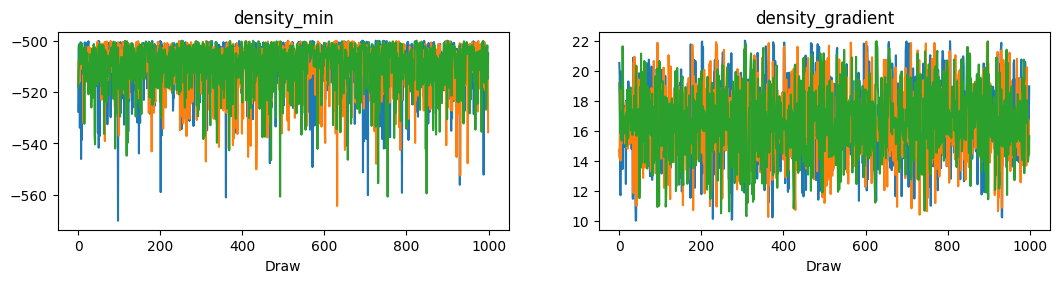

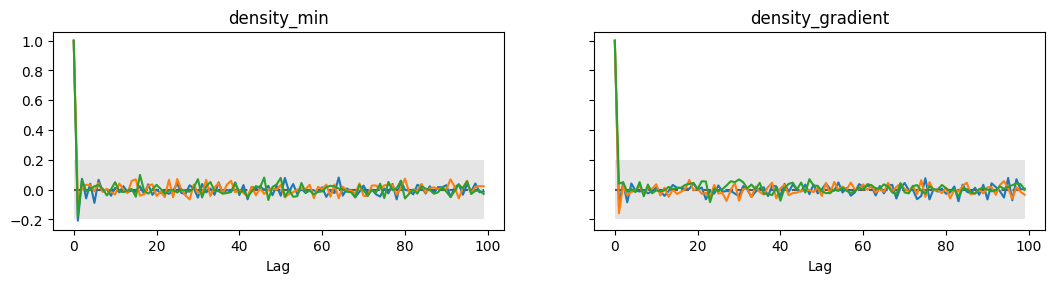

In [ ]:
import arviz as az
mcmc1_new = MCMC(NUTS(gp_model_narrow), num_warmup=500, num_samples=1000,
                num_chains=3, chain_method='vectorized')

mcmc1_new.run(rng_key, np.array(data['X']), np.array(data['g']), extra_fields=('accept_prob', 'num_steps'))
idata = az.from_numpyro(mcmc1_new)

# Convergence + ESS table
summary = az.summary(idata, var_names=["density_min", "density_gradient"], round_to=3)
print(summary)  # gives r_hat, ess_bulk, ess_tail, mcse

# Acceptance rate
accept = mcmc1_new.get_extra_fields()['accept_prob']
print(f"Mean acceptance probability: {accept.mean():.3f}")

# Trace plots (visual convergence check across chains)
az.plot_trace(idata, var_names=["density_min", "density_gradient"])

# Autocorrelation
az.plot_autocorr(idata, var_names=["density_min", "density_gradient"])

In [ ]:
samples1_new2 = mcmc1_new3.get_samples()

Max R-hat across all sites: 1.007
Min ESS bulk across all sites: 1985.802
                      mean      sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  \
k_length             1.098   0.451     0.589     1.907  1985.802  1915.011   
k_scale              3.367   1.992     1.487     6.776  2222.809  1916.380   
density_gradient    16.635   2.381    12.679    20.601  3277.139  1707.001   
density_min       -510.126   9.685  -528.809  -500.642  3304.690  1835.916   
B_D1_37            126.000   9.846   110.619   141.959  3333.432  1675.443   
noise_var            0.003   0.001     0.002     0.004  3634.180  1999.314   
B_D1_27           1726.220  31.622  1677.789  1773.852  3827.663  1980.020   
B_D1_35            567.441  25.317   522.779   602.352  3860.355  1732.414   
B_D1_36            316.096  14.443   301.655   342.424  3922.476  2057.712   
B_D1_7             914.493  33.301   867.619   970.443  4286.636  1845.918   

                  r_hat  mcse_mean  mcse_sd  
k_length          1.0

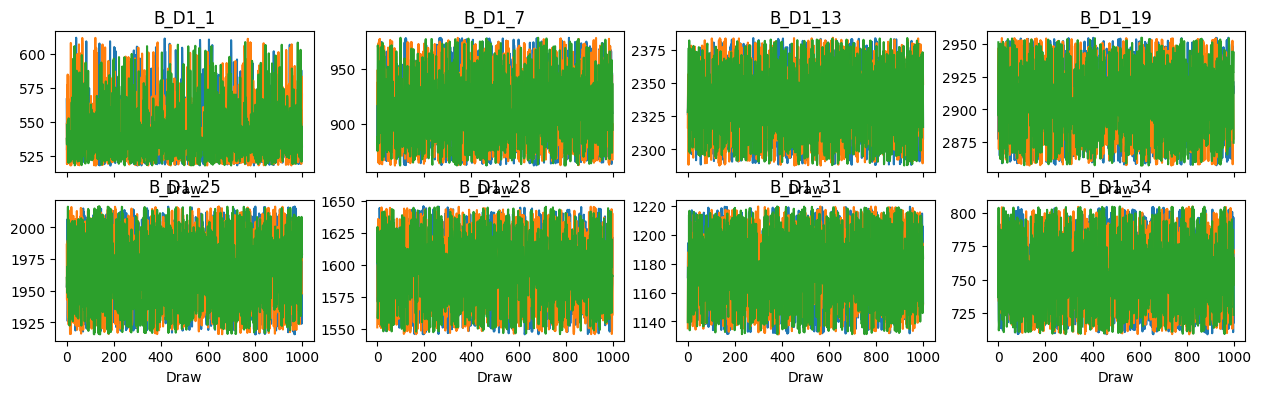

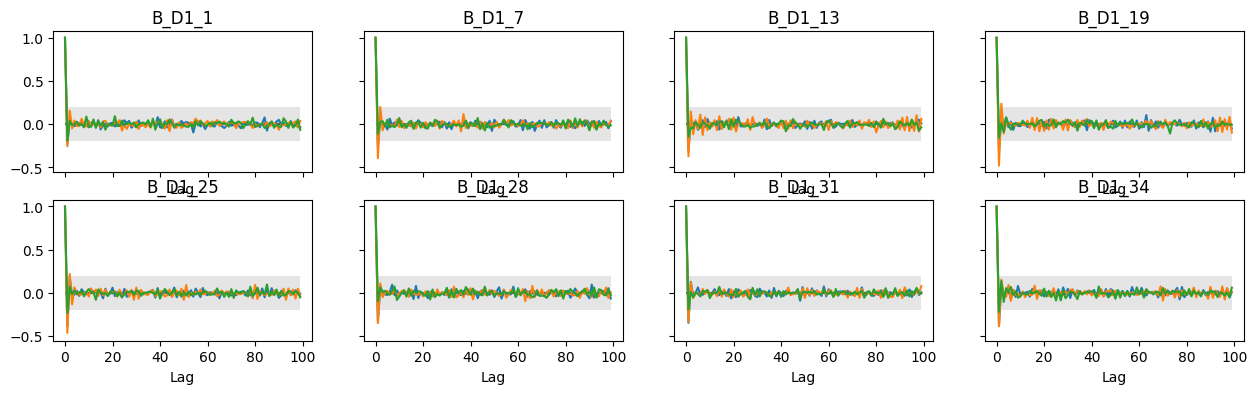

In [ ]:
import arviz as az


# (a) Worst-case across ALL sites — the single strongest evidence for the reviewer
full_summary = az.summary(idata, round_to=3)
print("Max R-hat across all sites:", full_summary['r_hat'].max())
print("Min ESS bulk across all sites:", full_summary['ess_bulk'].min())
print(full_summary.sort_values('ess_bulk').head(10))   # worst-mixing sites
print(full_summary.sort_values('r_hat', ascending=False).head(10))  # worst-converging sites

# (b) Focused check: low-index vs. high-index prisms (where bias grows)
representative = [1, 7, 13, 19, 25, 28, 31, 34]
d1_vars = [f"B_D1_{i}" for i in representative]
#d2_vars = [f"B_D2_{i}" for i in representative]

az.summary(idata, var_names=d1_vars , round_to=3)
az.plot_trace(idata, var_names=d1_vars)
az.plot_autocorr(idata, var_names=d1_vars)

sample: 100%|██████████| 1500/1500 [56:51<00:00,  2.27s/it]  


                     mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  \
density_min      -456.810  6.756  -469.555  -450.416  2713.393  1536.470   
density_gradient   14.284  2.114    10.870    17.542  2246.310  1677.183   

                  r_hat  mcse_mean  mcse_sd  
density_min       1.001      0.107    0.153  
density_gradient  1.000      0.042    0.021  
Mean acceptance probability: 0.943


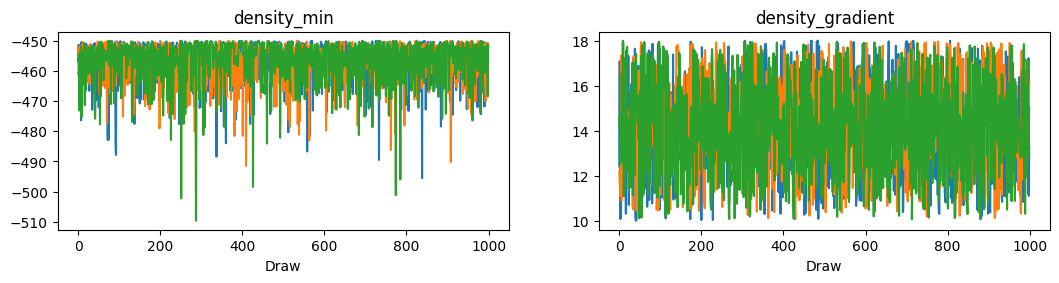

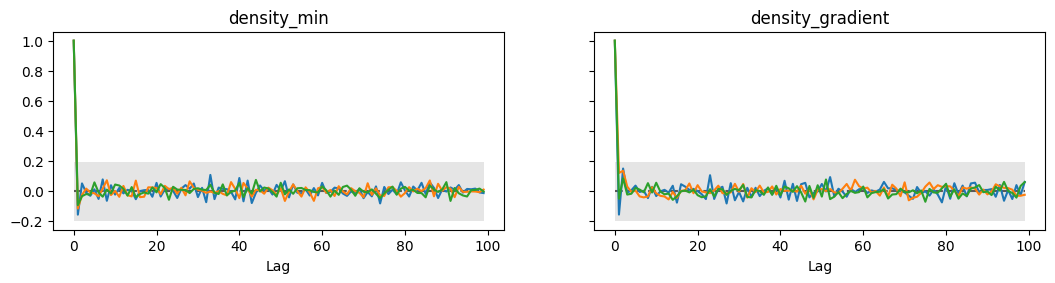

In [ ]:
import arviz as az
mcmc2 = MCMC(NUTS(gp_model_sparse), num_warmup=500, num_samples=1000,
                num_chains=3, chain_method='vectorized')

mcmc2.run(rng_key, np.array(data['X']), np.array(data['g']), extra_fields=('accept_prob', 'num_steps'))
idata2 = az.from_numpyro(mcmc2)

# Convergence + ESS table
summary2 = az.summary(idata2, var_names=["density_min", "density_gradient"], round_to=3)
print(summary2)  # gives r_hat, ess_bulk, ess_tail, mcse

# Acceptance rate
accept2 = mcmc2.get_extra_fields()['accept_prob']
print(f"Mean acceptance probability: {accept2.mean():.3f}")

# Trace plots (visual convergence check across chains)
az.plot_trace(idata2, var_names=["density_min", "density_gradient"])

# Autocorrelation
az.plot_autocorr(idata2, var_names=["density_min", "density_gradient"])

Max R-hat across all sites: 1.007
Min ESS bulk across all sites: 1248.94
                      mean       sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  \
k_scale              5.014    2.772     2.333     9.836  1248.940  1578.676   
k_length             0.813    0.305     0.474     1.348  1260.266  1614.198   
B_D1_36            618.904  140.790   427.583   886.809  1773.698  1192.649   
B_D1_35            817.460  185.551   551.289  1153.604  1924.735  1097.292   
B_D1_1             669.234  260.589   344.014  1167.248  2120.927  1568.006   
B_D1_4            1001.048  254.718   592.322  1406.901  2126.347  1407.860   
B_D1_2             566.253  189.071   365.182   950.126  2133.004  1527.419   
density_gradient    14.284    2.114    10.870    17.542  2246.310  1677.183   
B_D1_3             898.845  239.717   537.787  1316.957  2351.999  1390.245   
B_D1_5             997.604  269.431   600.724  1459.307  2484.571  1523.522   

                  r_hat  mcse_mean  mcse_sd  
k_scale    

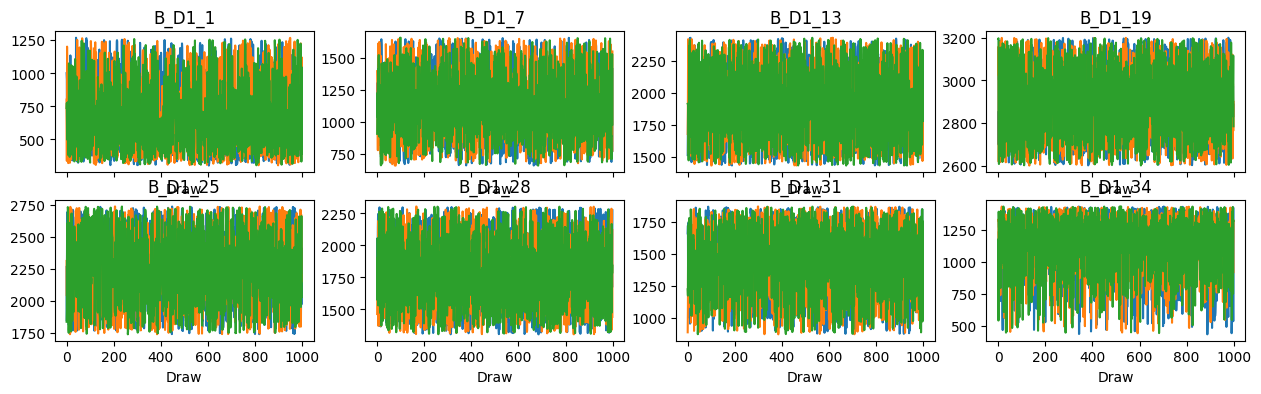

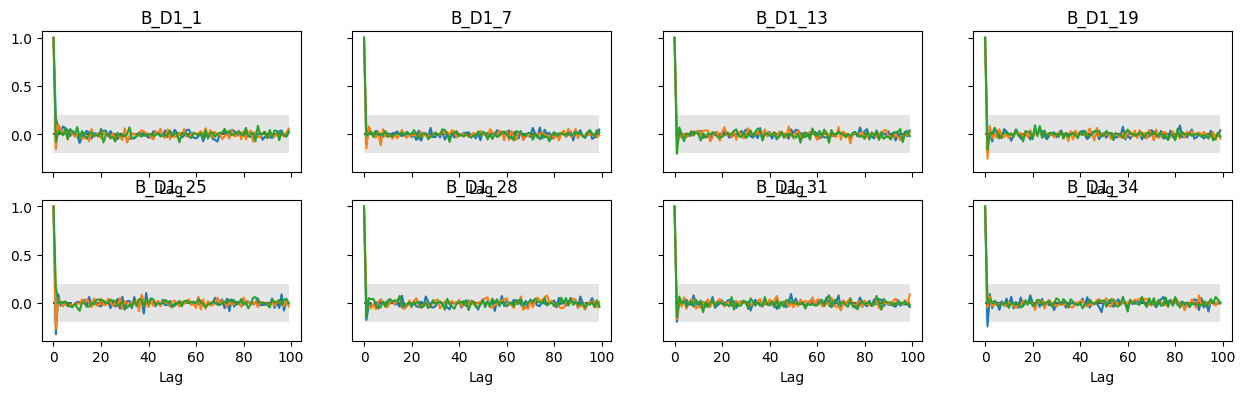

In [ ]:
import arviz as az


# (a) Worst-case across ALL sites — the single strongest evidence for the reviewer
full_summary = az.summary(idata2, round_to=3)
print("Max R-hat across all sites:", full_summary['r_hat'].max())
print("Min ESS bulk across all sites:", full_summary['ess_bulk'].min())
print(full_summary.sort_values('ess_bulk').head(10))   # worst-mixing sites
print(full_summary.sort_values('r_hat', ascending=False).head(10))  # worst-converging sites

# (b) Focused check: low-index vs. high-index prisms (where bias grows)
representative = [1, 7, 13, 19, 25, 28, 31, 34]
d1_vars = [f"B_D1_{i}" for i in representative]
#d2_vars = [f"B_D2_{i}" for i in representative]

az.summary(idata2, var_names=d1_vars , round_to=3)
az.plot_trace(idata2, var_names=d1_vars)
az.plot_autocorr(idata2, var_names=d1_vars)

In [ ]:
def Cal_vertical_3_posterior_predictive(x, mcmc_samples, n_draws=200, seed=0):
    """
    Posterior-predictive reconstruction of the gravity anomaly.

    Instead of evaluating the forward model once at the marginal means
    of B_D1 / density_min / density_gradient (which ignores their
    correlation), this evaluates the forward model at each retained
    MCMC draw and averages the resulting curves. Correct whenever
    parameters are correlated (see depth-density trade-off plot) and
    noise_var is small, since each draw should individually fit the
    data closely.
    """
    n_total = mcmc_samples["density_min"].shape[0]
    rng = np.random.default_rng(seed)
    draw_idx = rng.choice(n_total, size=min(n_draws, n_total), replace=False)

    y_stack = jnp.zeros((len(draw_idx), len(x)))

    for d_i, s in enumerate(draw_idx):
        density_grad = mcmc_samples["density_gradient"][s]
        den_min      = mcmc_samples["density_min"][s]

        y1_v = jnp.zeros(len(x))
        for i in range(n):
            B_D1     = mcmc_samples[f"B_D1_{i+1}"][s]   # per-draw depth, NOT the mean
            #density_grad = mcmc_samples[f"density_gradient_{i+1}"][s]
            z_grid   = np.arange(0, float(B_D1), 100)
            n_layers = len(z_grid) - 1
            g_prism  = jnp.zeros(len(x))

            for k in range(n_layers):
                z_top = float(z_grid[k]) + 0.001
                z_bot = (float(z_grid[k + 1]) + 0.001
                         if k < n_layers - 1
                         else float(B_D1) + 0.001)
                rho = den_min + density_grad * k
                g_prism = g_prism + g_ano(x, co[i], wid[i], z_bot, z_top, rho)

            y1_v = y1_v + g_prism

        y_stack = y_stack.at[d_i].set(y1_v)

    y_mean = y_stack.mean(axis=0)   # <- use this as "Reconstructed Anomaly"
    y_std  = y_stack.std(axis=0)    # <- and this for the uncertainty band
    return y_mean, y_std

In [ ]:
pred_mean, pred_std = Cal_vertical_3_posterior_predictive(
    np.array(co), samples1_new2)
pred_mean = np.array(pred_mean)
pred_std  = np.array(pred_std)

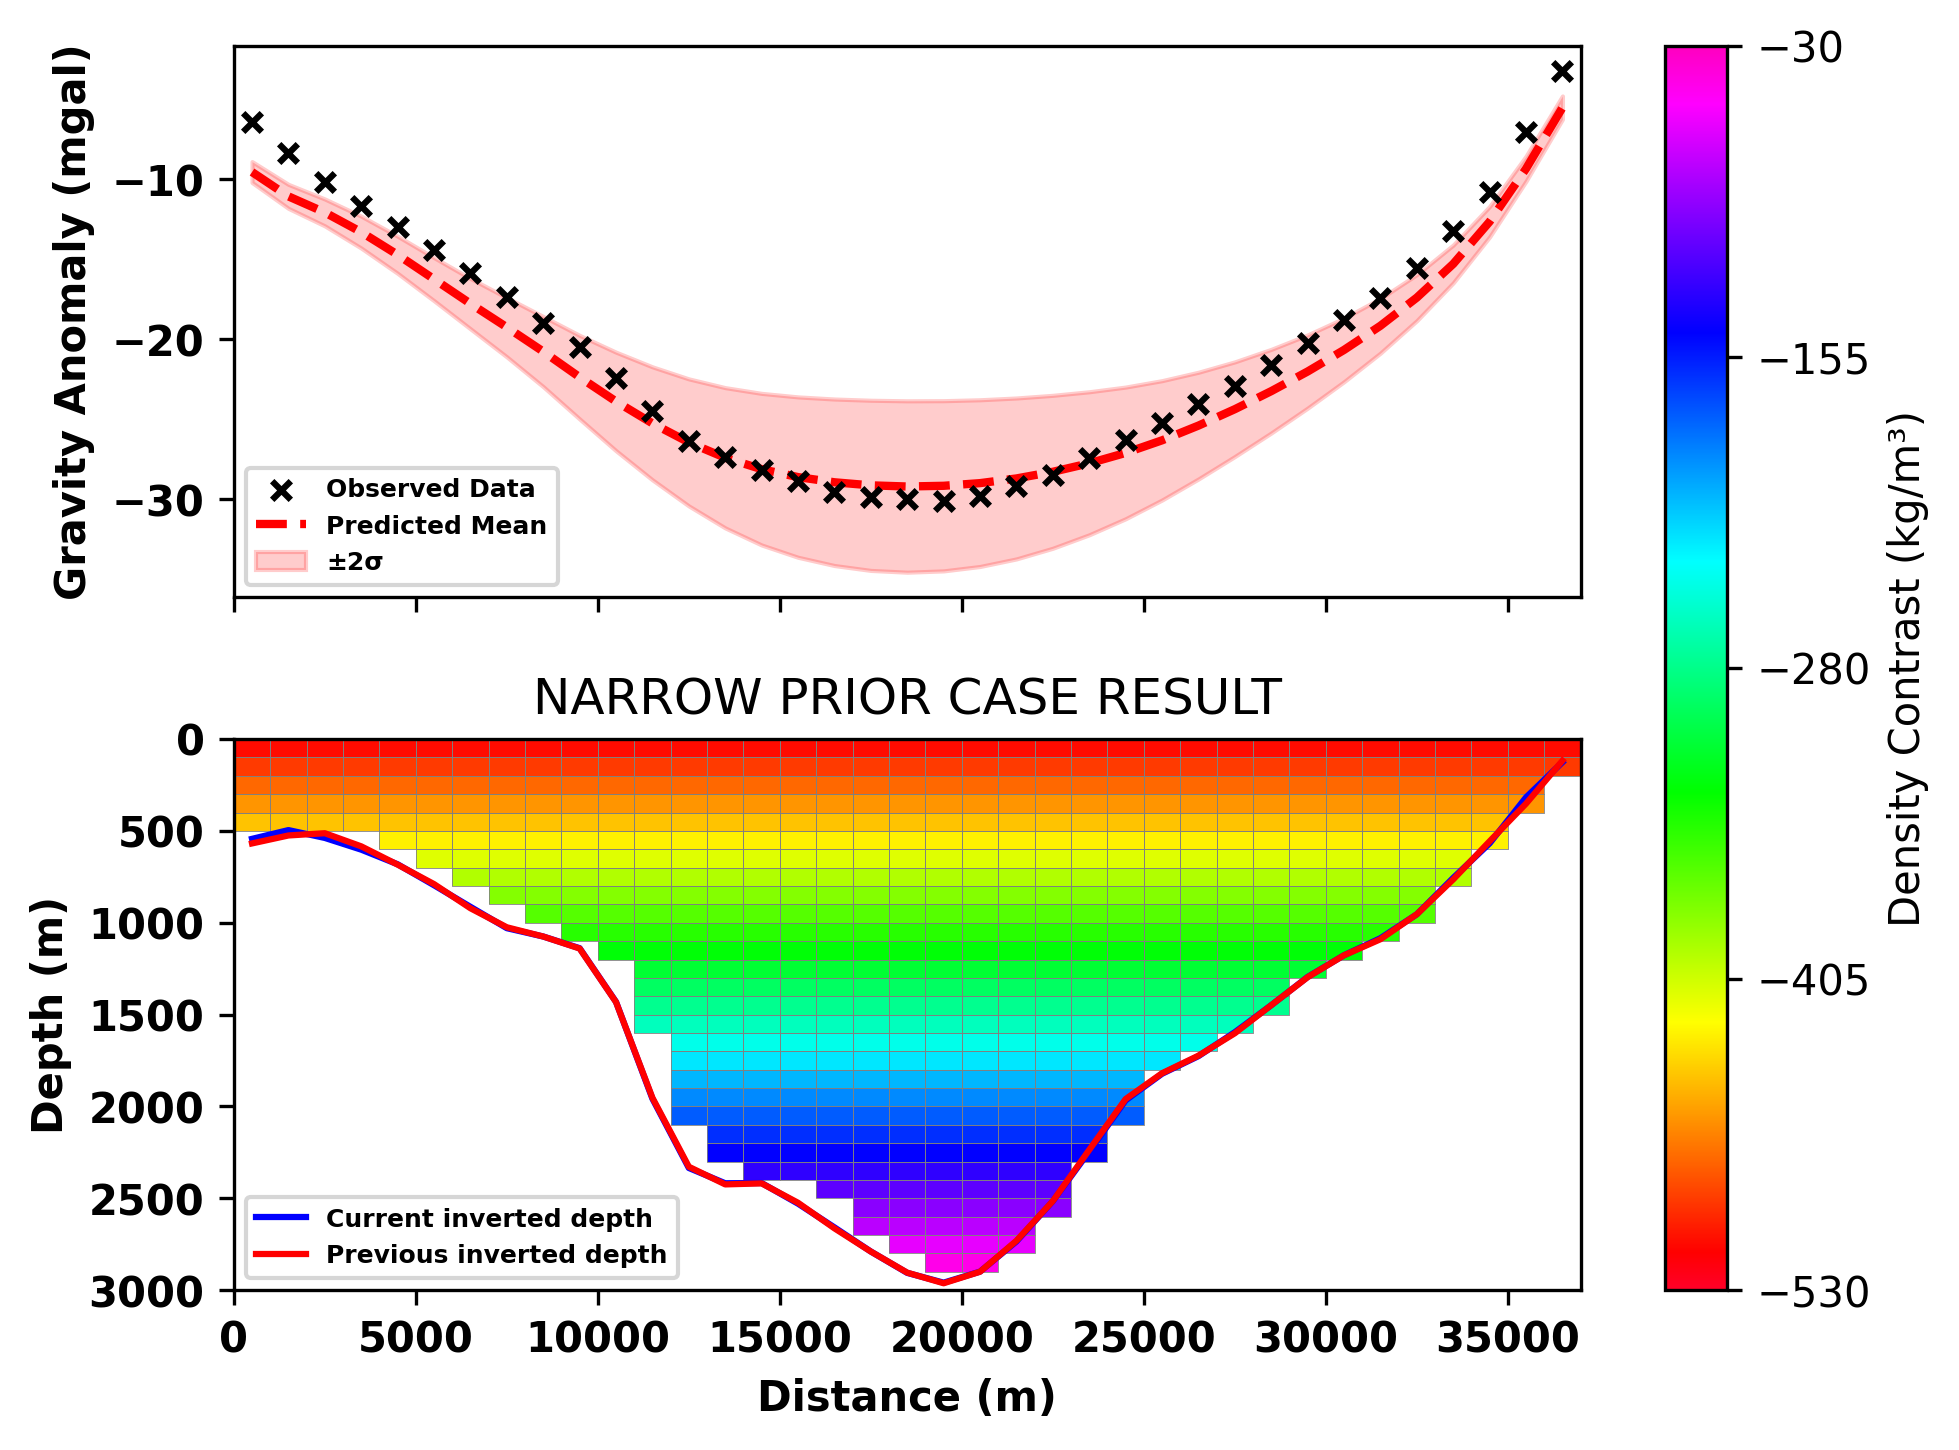

In [ ]:
params7 = mcmc1_new3.get_samples()
density1_min_narrow   = params7["density_min"].mean()
density1_grad = params7["density_gradient"].mean()
inverted_depths_narrow= np.array([params7[f"B_D1_{i+1}"].mean() for i in range(n)])

import matplotlib as mpl

# ═══════════════════════════════════════════════════════════════════════════════
# 7.  PLOT
# ═══════════════════════════════════════════════════════════════════════════════
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1.3)
fig.dpi = 300

# ── Build prism geometry ──────────────────────────────────────────────────────
bd1 = inverted_depths_narrow
xs_V    = np.zeros(n + 1)
xs_V[0] = co[0]  - wid[0]  * 0.5
xs_V[n] = co[n-1]+ wid[n-1]* 0.5
for i in range(1, n):
    xs_V[i] = co[i-1] + 0.5 * wid[i-1]

zs1_V    = np.zeros(n + 1)
zs1_V[0] = inverted_depths_narrow[0]
zs1_V[n] = inverted_depths_narrow[n-1]
for i in range(1, n):
    zs1_V[i] = (bd1[i-1] + bd1[i]) * 0.5

density_top = np.full(n, density1_min_narrow)

cmap_V   = plt.get_cmap('gist_rainbow', 1000)
maximum_V = -30
minimum_V = -530
diff_V    = maximum_V - minimum_V
plt.title("NARROW PRIOR CASE RESULT")

# ── First layer (30 m resolution for shallow detail) ─────────────────────────
for i in range(n):
    z_v_1    = np.arange(0, zs1_V[i] + 1, 100)
    den_top  = density1_min_narrow
    den_grad = density1_grad

    for j in range(0, 1):
        den1_V      = den_top + j * den_grad
        index_value = (den1_V - minimum_V) / diff_V
        color_V     = cmap_V(index_value)
        x_left, x_right = xs_V[i], xs_V[i+1]
        z_top_,  z_bot_  = z_v_1[0], z_v_1[j+1]
        coord_V = [[x_left, z_top_], [x_right, z_top_],
                   [x_right, z_bot_], [x_left,  z_bot_]]
        coord_V.append(coord_V[0])
        x1_V, y1_V = zip(*coord_V)
        axs[1].plot(x1_V, y1_V, 'grey', linewidth=0.2)
        axs[1].fill(x1_V, y1_V, facecolor=color_V)

# ── Remaining layers (100 m resolution) ──────────────────────────────────────
for i in range(n):
    z_v_1    = np.arange(0, zs1_V[i] + 1, 100)
    den_top  = density1_min_narrow
    den_grad = density1_grad

    for j in range(1, len(z_v_1) - 1):
        den1_V      = den_top + j * den_grad
        index_value = (den1_V - minimum_V) / diff_V
        color_V     = cmap_V(index_value)
        x_left, x_right = xs_V[i], xs_V[i+1]
        z_top_,  z_bot_  = z_v_1[j], z_v_1[j+1]
        coord_V = [[x_left, z_top_], [x_right, z_top_],
                   [x_right, z_bot_], [x_left,  z_bot_]]
        coord_V.append(coord_V[0])
        x1_V, y1_V = zip(*coord_V)
        axs[1].plot(x1_V, y1_V, 'grey', linewidth=0.2)
        #axs[1].legend(['Inverted Model','True Depth Profile',],prop=legend_properties)

        axs[1].fill(x1_V, y1_V, facecolor=color_V)
        axs[1].set_xlim(0, 37000)
        axs[1].set_ylim(3000, 0)
axs[1].plot(co,inverted_depths_narrow,'blue',label="Current inverted depth")
axs[1].plot(co,z_prev,'red',label="Previous inverted depth")
axs[1].set_xlim(0, 37000)
axs[1].set_ylim(3000, 0)
# ── Colorbar ──────────────────────────────────────────────────────────────────
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
sm   = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
plt.colorbar(
    sm,
    ticks=np.linspace(minimum_V, maximum_V, 5),
    ax=axs.ravel().tolist(),
    label='Density Contrast (kg/m³)'
)

# ── Top panel: gravity fit ────────────────────────────────────────────────────
axs[0].scatter(co, g, marker='x', s=20, c='k', label="Observed Data", zorder=2)
axs[0].plot(co, pred_mean, '--', c='red', linewidth=2,label='Predicted Mean', zorder=1)
#axs[0].plot(co,Cal_vertical_3(co), '--', c='red', linewidth=2,label='Reconstructed Anomaly from Inverted Result', zorder=1)

axs[0].fill_between(
    co,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    color='r', alpha=0.2, label="±2σ", zorder=0
)
#axs[0].fill_between(X_test_fine,pred_mean2 - 2 * pred_std2,pred_mean2 + 2 * pred_std2,color='r', alpha=0.2, label="±2σ", zorder=0)
axs[0].set_xlim(0, 37000)

legend_properties = {'weight': 'bold', 'size': '7'}
axs[0].legend(prop=legend_properties)

# ── Axis labels and tick formatting ──────────────────────────────────────────
axs[0].set_ylabel("Gravity Anomaly (mgal)", fontsize=10, weight='bold')
axs[1].set_xlabel("Distance (m)",            fontsize=10, weight='bold')
axs[1].set_ylabel("Depth (m)",               fontsize=10, weight='bold')

for ax in axs:
    plt.setp(ax.get_xticklabels(), weight='bold')
    plt.setp(ax.get_yticklabels(), weight='bold')
plt.setp(axs[0].get_xticklabels(), visible=False)

#plt.savefig("gp_inversion_fixed_result.png", dpi=300, bbox_inches='tight')
axs[0].set_xlim(0, 37000)

legend_properties = {'weight': 'bold', 'size': '6'}
axs[0].legend(prop=legend_properties)
axs[1].legend(prop=legend_properties)

# ── Axis labels and tick formatting ──────────────────────────────────────────
axs[0].set_ylabel("Gravity Anomaly (mgal)", fontsize=10, weight='bold')
axs[1].set_xlabel("Distance (m)",            fontsize=10, weight='bold')
axs[1].set_ylabel("Depth (m)",               fontsize=10, weight='bold')

for ax in axs:
    plt.setp(ax.get_xticklabels(), weight='bold')
    plt.setp(ax.get_yticklabels(), weight='bold')
plt.setp(axs[0].get_xticklabels(), visible=False)


In [ ]:
# ── GP model (used by MCMC) ───────────────────────────────────────────────────
def gp_model_sparse(X, y=None):
    X_phys    = jnp.array(X).reshape(-1, 1)
    x_phys_1d = X_phys[:, 0]
    X_norm    = normalize_X(X_phys)
    kernel_params = custom_kernel_prior()
    # FIX 3: noise_var prior loosened so kernel is not crowded out
    noise_var = numpyro.sample("noise_var", dist.HalfNormal(1.0))
    mean_params = Bayes_sparse_prior()
    mean_vec    = Bayes_vertical_new3(x_phys_1d, mean_params)
    K = custom_Matern_kernel(
        X_norm, X_norm,
        params={"k_scale": kernel_params["k_scale"],
                "k_length": kernel_params["k_length"]},
        noise=noise_var
    )
    numpyro.sample("y",
                   dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K),
                   obs=y)

In [ ]:
def gp_model_sparse(X, y=None):
    # FIX: Use jnp.reshape instead of jnp.array
    X_phys    = jnp.reshape(X, (-1, 1))
    x_phys_1d = X_phys[:, 0]
    X_norm    = normalize_X(X_phys)

    kernel_params = custom_kernel_prior()
    noise_var = numpyro.sample("noise_var", dist.HalfNormal(1.0))
    mean_params = Bayes_sparse_prior()
    mean_vec    = Bayes_vertical_new3(x_phys_1d, mean_params)

    K = custom_Matern_kernel(
        X_norm, X_norm,
        params={"k_scale": kernel_params["k_scale"],
                "k_length": kernel_params["k_length"]},
        noise=noise_var
    )

    numpyro.sample("y",
                   dist.MultivariateNormal(loc=mean_vec, covariance_matrix=K),
                   obs=y)

In [ ]:
rng_key = jax.random.PRNGKey(0)
rng_key, rng_key_predict = jax.random.split(rng_key)
mcmc2 = MCMC(NUTS(gp_model_sparse), num_warmup=500, num_samples=1000,
                num_chains=3, chain_method='vectorized')

# Step 2: Run ONLY the warmup phase, collecting samples drawn during warmup
#mcmc2.warmup(rng_key, np.array(data['X']), np.array(data['g']), collect_warmup=True)

# Step 3: Extract warmup samples (available right after .warmup())
#warmup_samples2 = mcmc2.get_samples()
#print("Warmup samples collected:", warmup_samples1[depth_key].shape)  # (num_warmup,)

#mcmc2.run(rng_key,data['X'],data['g'])
mcmc2.run(rng_key, jnp.array(data['X'].values), jnp.array(data['g'].values))
#mcmc1_new3.run(rng_key, np.array(data['X']), np.array(data['g']))
samples2 = mcmc2.get_samples()

sample: 100%|██████████| 1500/1500 [2:27:18<00:00,  5.89s/it] 


In [ ]:
pred_mean2, pred_std2 = Cal_vertical_3_posterior_predictive(
    np.array(co), samples2)
pred_mean2 = np.array(pred_mean2)
pred_std2  = np.array(pred_std2)

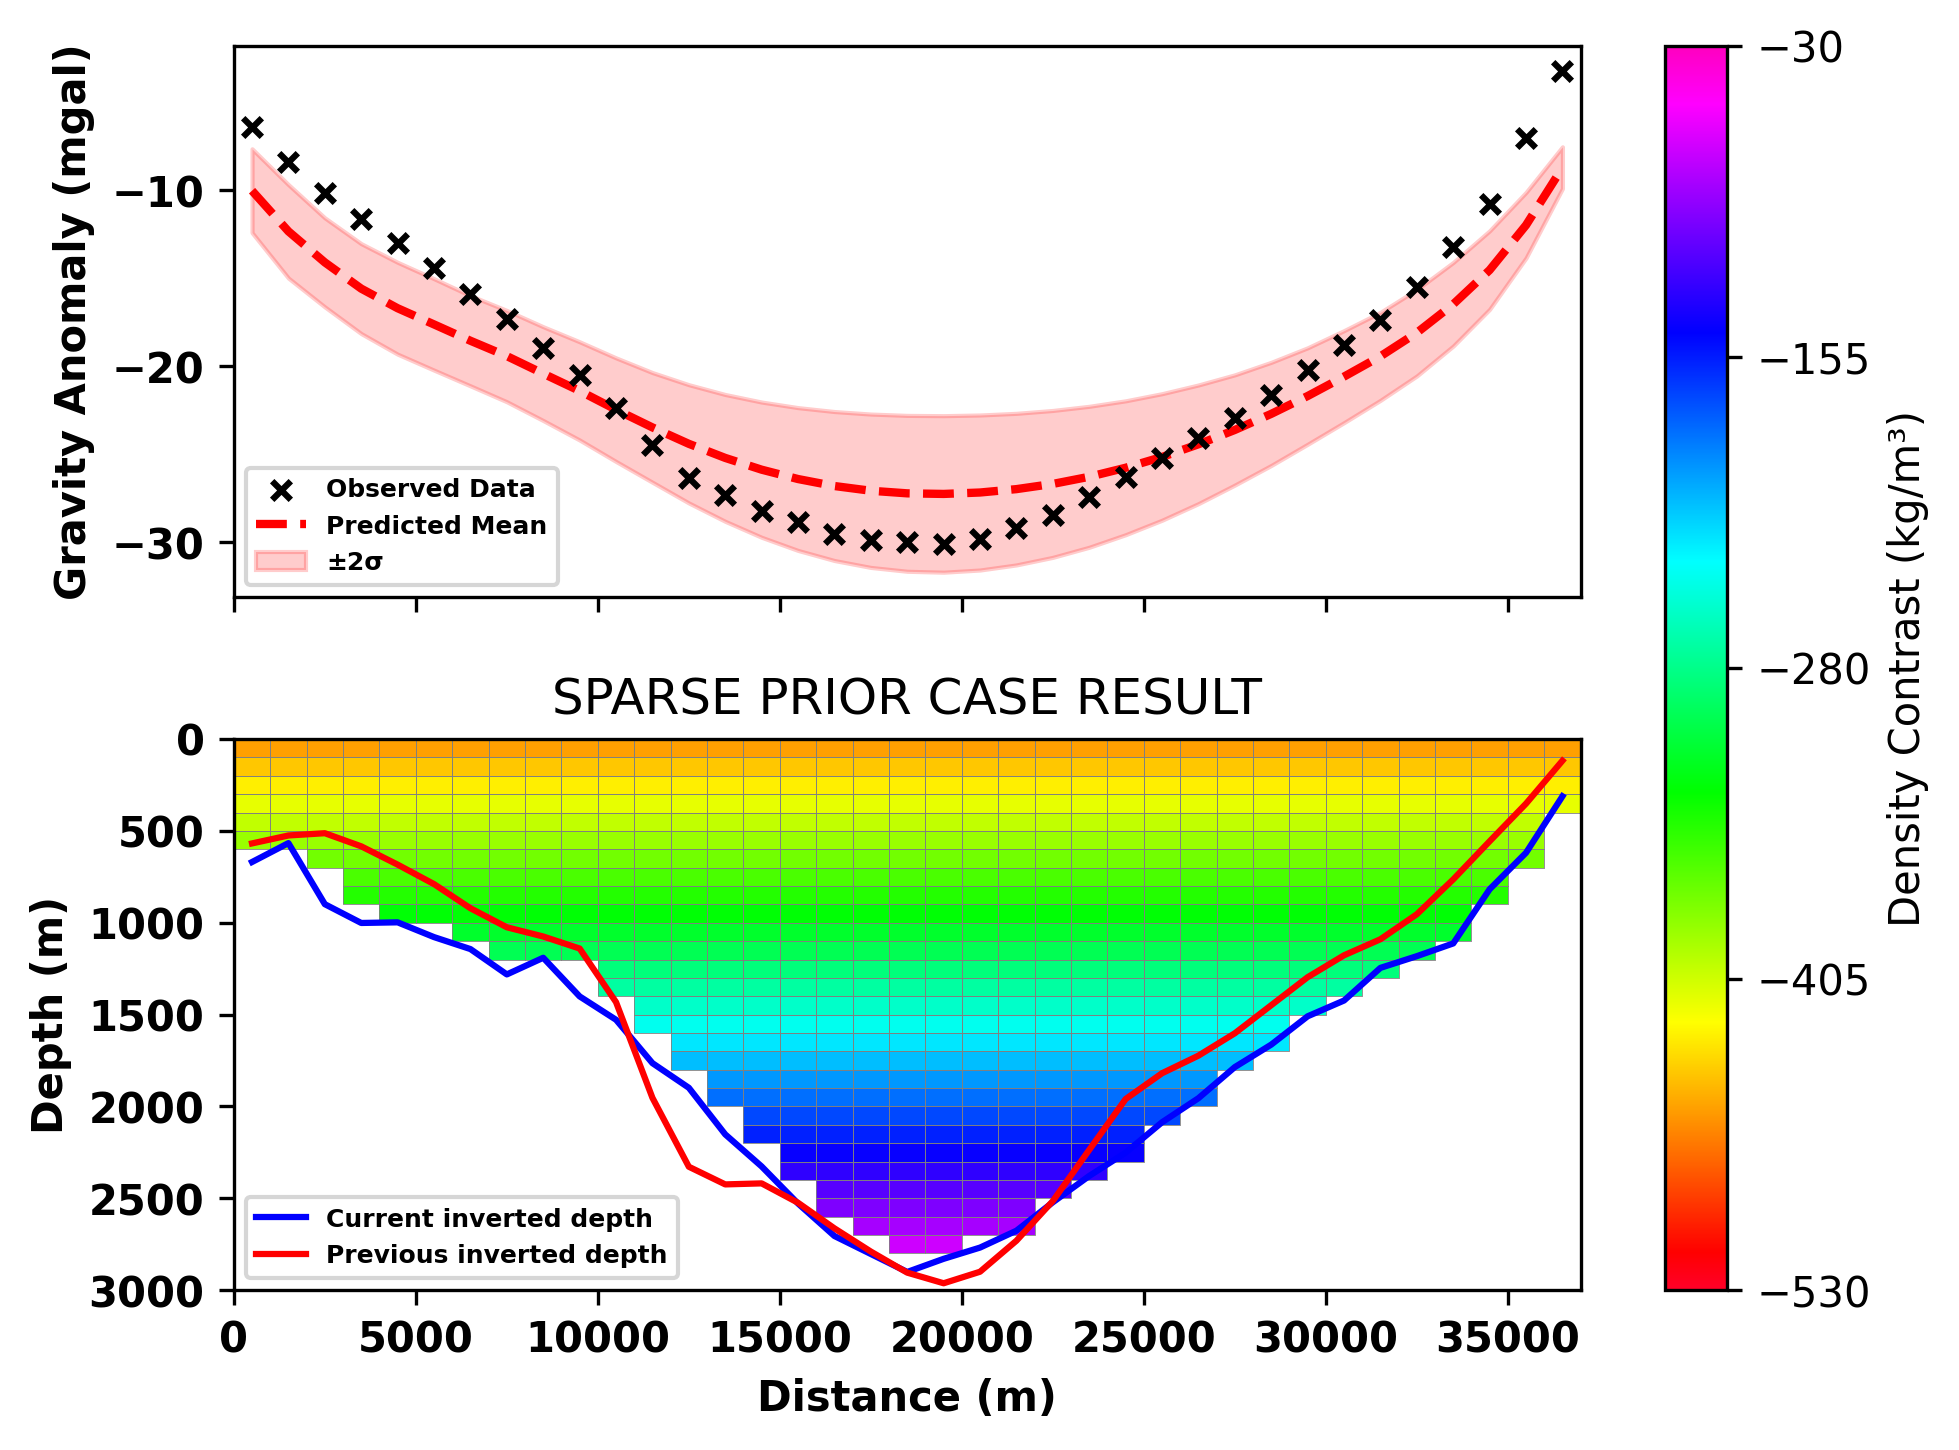

In [ ]:
params8 = mcmc2.get_samples()
density1_min_sparse   = params8["density_min"].mean()
density1_grad_sparse = params8["density_gradient"].mean()
inverted_depths_sparse= np.array([params8[f"B_D1_{i+1}"].mean() for i in range(n)])

import matplotlib as mpl

# ═══════════════════════════════════════════════════════════════════════════════
# 7.  PLOT
# ═══════════════════════════════════════════════════════════════════════════════
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1.3)
fig.dpi = 300
plt.title("SPARSE PRIOR CASE RESULT")

axs[0].scatter(co, g, marker='x', s=20, c='k', label="Observed Data", zorder=2)
axs[0].plot(co, pred_mean2, '--', c='red', linewidth=2,label='Predicted Mean', zorder=1)
#axs[0].plot(co,Cal_vertical_3(co), '--', c='red', linewidth=2,label='Reconstructed Anomaly from Inverted Result', zorder=1)

axs[0].fill_between(
    co,
    pred_mean2 - 2 * pred_std2,
    pred_mean2 + 2 * pred_std2,
    color='r', alpha=0.2, label="±2σ", zorder=0
)
#axs[0].fill_between(X_test_fine,pred_mean2 - 2 * pred_std2,pred_mean2 + 2 * pred_std2,color='r', alpha=0.2, label="±2σ", zorder=0)
axs[0].set_xlim(0, 37000)

legend_properties = {'weight': 'bold', 'size': '7'}
axs[0].legend(prop=legend_properties)

# ── Axis labels and tick formatting ──────────────────────────────────────────
axs[0].set_ylabel("Gravity Anomaly (mgal)", fontsize=10, weight='bold')
# ── Build prism geometry ──────────────────────────────────────────────────────
bd1 = inverted_depths_sparse
xs_V    = np.zeros(n + 1)
xs_V[0] = co[0]  - wid[0]  * 0.5
xs_V[n] = co[n-1]+ wid[n-1]* 0.5
for i in range(1, n):
    xs_V[i] = co[i-1] + 0.5 * wid[i-1]

zs1_V    = np.zeros(n + 1)
zs1_V[0] = inverted_depths_sparse[0]
zs1_V[n] = inverted_depths_sparse[n-1]
for i in range(1, n):
    zs1_V[i] = (bd1[i-1] + bd1[i]) * 0.5

density_top = np.full(n, density1_min_sparse)

cmap_V   = plt.get_cmap('gist_rainbow', 1000)
maximum_V = -30
minimum_V = -530
diff_V    = maximum_V - minimum_V

# ── First layer (30 m resolution for shallow detail) ─────────────────────────
for i in range(n):
    z_v_1    = np.arange(0, zs1_V[i] + 1, 100)
    den_top  = density1_min_sparse
    den_grad = density1_grad_sparse

    for j in range(0, 1):
        den1_V      = den_top + j * den_grad
        index_value = (den1_V - minimum_V) / diff_V
        color_V     = cmap_V(index_value)
        x_left, x_right = xs_V[i], xs_V[i+1]
        z_top_,  z_bot_  = z_v_1[0], z_v_1[j+1]
        coord_V = [[x_left, z_top_], [x_right, z_top_],
                   [x_right, z_bot_], [x_left,  z_bot_]]
        coord_V.append(coord_V[0])
        x1_V, y1_V = zip(*coord_V)
        axs[1].plot(x1_V, y1_V, 'grey', linewidth=0.2)
        axs[1].fill(x1_V, y1_V, facecolor=color_V)

# ── Remaining layers (100 m resolution) ──────────────────────────────────────
for i in range(n):
    z_v_1    = np.arange(0, zs1_V[i] + 1, 100)
    den_top  = density1_min_sparse
    den_grad = density1_grad_sparse

    for j in range(1, len(z_v_1) - 1):
        den1_V      = den_top + j * den_grad
        index_value = (den1_V - minimum_V) / diff_V
        color_V     = cmap_V(index_value)
        x_left, x_right = xs_V[i], xs_V[i+1]
        z_top_,  z_bot_  = z_v_1[j], z_v_1[j+1]
        coord_V = [[x_left, z_top_], [x_right, z_top_],
                   [x_right, z_bot_], [x_left,  z_bot_]]
        coord_V.append(coord_V[0])
        x1_V, y1_V = zip(*coord_V)
        axs[1].plot(x1_V, y1_V, 'grey', linewidth=0.2)
        #axs[1].legend(['Inverted Model','True Depth Profile',],prop=legend_properties)

        axs[1].fill(x1_V, y1_V, facecolor=color_V)
        axs[1].set_xlim(0, 37000)
        axs[1].set_ylim(3000, 0)
axs[1].plot(co,inverted_depths_sparse,'blue',label="Current inverted depth")
axs[1].plot(co,z_prev,'red',label="Previous inverted depth")
axs[1].set_xlim(0, 37000)

axs[1].set_ylim(3000, 0)
# ── Colorbar ──────────────────────────────────────────────────────────────────
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
sm   = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
plt.colorbar(
    sm,
    ticks=np.linspace(minimum_V, maximum_V, 5),
    ax=axs.ravel().tolist(),
    label='Density Contrast (kg/m³)'
)

# ── Top panel: gravity fit ────────────────────────────────────────────────────


axs[1].set_xlabel("Distance (m)",            fontsize=10, weight='bold')
axs[1].set_ylabel("Depth (m)",               fontsize=10, weight='bold')

for ax in axs:
    plt.setp(ax.get_xticklabels(), weight='bold')
    plt.setp(ax.get_yticklabels(), weight='bold')
plt.setp(axs[0].get_xticklabels(), visible=False)

#plt.savefig("gp_inversion_fixed_result.png", dpi=300, bbox_inches='tight')
axs[0].set_xlim(0, 37000)

legend_properties = {'weight': 'bold', 'size': '6'}
axs[0].legend(prop=legend_properties)
axs[1].legend(prop=legend_properties)

# ── Axis labels and tick formatting ──────────────────────────────────────────
axs[0].set_ylabel("Gravity Anomaly (mgal)", fontsize=10, weight='bold')
axs[1].set_xlabel("Distance (m)",            fontsize=10, weight='bold')
axs[1].set_ylabel("Depth (m)",               fontsize=10, weight='bold')
for ax in axs:
    plt.setp(ax.get_xticklabels(), weight='bold')
    plt.setp(ax.get_yticklabels(), weight='bold')
plt.setp(axs[0].get_xticklabels(), visible=False)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def confidence_ellipse_points(x, y, n_std=2.0, n_points=100):
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.linspace(0, 2 * np.pi, n_points)
    ellipse = np.array([np.cos(theta), np.sin(theta)]) * n_std * np.sqrt(vals[:, None])
    ellipse = vecs @ ellipse
    return ellipse[0] + mean_x, ellipse[1] + mean_y


def _plot_single_prism(fig, subplot_spec, samples_sparse, samples_narrow,
                        depth_key, density_key, prism_idx, n_std, show_legend=False):
    """Draws one main+top+right marginal panel inside a given outer-grid cell."""
    d_sparse   = np.array(samples_sparse[depth_key])
    d_narrow   = np.array(samples_narrow[depth_key])
    rho_sparse = samples_sparse[density_key]
    rho_narrow = samples_narrow[density_key]

    inner = GridSpecFromSubplotSpec(4, 4, subplot_spec=subplot_spec, hspace=0.05, wspace=0.05)
    ax_main  = fig.add_subplot(inner[1:4, 0:3])
    ax_top   = fig.add_subplot(inner[0, 0:3], sharex=ax_main)
    ax_right = fig.add_subplot(inner[1:4, 3], sharey=ax_main)

    c_sparse, c_narrow = "darkorange", "navy"

    ax_main.scatter(d_sparse, rho_sparse, s=8, alpha=0.25, color=c_sparse, label="Sparse prior")
    ax_main.scatter(d_narrow, rho_narrow, s=8, alpha=0.25, color=c_narrow, label="Narrow prior")

    ex, ey = confidence_ellipse_points(d_sparse, rho_sparse, n_std=n_std)
    ax_main.plot(ex, ey, color=c_sparse, lw=2)
    ex, ey = confidence_ellipse_points(d_narrow, rho_narrow, n_std=n_std)
    ax_main.plot(ex, ey, color=c_narrow, lw=2)

    ax_main.scatter(d_sparse.mean(), rho_sparse.mean(), color=c_sparse, edgecolor='k', s=30, zorder=5)
    ax_main.scatter(d_narrow.mean(), rho_narrow.mean(), color=c_narrow, edgecolor='k', s=30, zorder=5)

    ax_main.set_xlabel(f"Depth ({depth_key})", fontsize=9)
    ax_main.set_ylabel(f"Density ({density_key})", fontsize=9)
    ax_main.tick_params(labelsize=8)
    if show_legend:
        ax_main.legend(loc="lower left", fontsize=8)

    ax_top.hist(d_sparse, bins=25, color=c_sparse, alpha=0.5, density=True)
    ax_top.hist(d_narrow, bins=25, color=c_narrow, alpha=0.5, density=True)
    ax_top.axis("off")
    ax_top.set_title(f"Prism {prism_idx}", fontsize=11, pad=8)

    ax_right.hist(rho_sparse, bins=25, orientation="horizontal", color=c_sparse, alpha=0.5, density=True)
    ax_right.hist(rho_narrow, bins=25, orientation="horizontal", color=c_narrow, alpha=0.5, density=True)
    ax_right.axis("off")

    return ax_main,d_sparse.mean()


def plot_2d_comparison_multi(samples_sparse, samples_narrow, prism_indices,
                              depth_key_fmt="B_D1_{}", density_key_fmt="density_min",
                              n_std=2.0, n_cols=3, panel_size=3.2):
    n_prisms = len(prism_indices)
    n_cols   = min(n_cols, n_prisms)
    n_rows   = int(np.ceil(n_prisms / n_cols))

    fig = plt.figure(figsize=(panel_size * n_cols, panel_size * n_rows))
    outer = GridSpec(n_rows, n_cols, figure=fig, hspace=0.4, wspace=0.35)

    axes_main = []
    for idx, prism_idx in enumerate(prism_indices):
        depth_key   = depth_key_fmt.format(prism_idx)
        density_key = density_key_fmt.format(prism_idx)
        row, col = divmod(idx, n_cols)

        #axes_main.append(ax_main)
        ax_main, _mean_val = _plot_single_prism(
            fig, outer[row, col], samples_sparse, samples_narrow,
            depth_key, density_key, prism_idx, n_std,
            show_legend=(idx == 0)
        )
        axes_main.append(ax_main)

    fig.suptitle("Depth–Density Trade-off Across Prisms", fontsize=14, y=1.02)
    plt.show()
    return fig, axes_main


# ============================================================
# USER-EDITABLE SECTION
# ============================================================
samples_sparse = samples2
samples_narrow = samples1_new2
prism_indices  = [1,4,7,10,13,16,19,22,25,28,31,34,36]   # <-- any set of prisms you want side by side
n_std          = 2.0

# Sanity check before plotting — you flagged this exact assignment pattern before
# (samples_sparse = samples1 / samples_narrow = samples2) as the source of a bug
# where both ended up identical due to variable reuse during MCMC extraction.
assert not np.allclose(
    np.array(samples_sparse["B_D1_5"]), np.array(samples_narrow["B_D1_5"])
), "samples1 and samples2 look identical — check the MCMC extraction cells above."

fig, axes = plot_2d_comparison_multi(samples_sparse, samples_narrow, prism_indices, n_std=n_std)

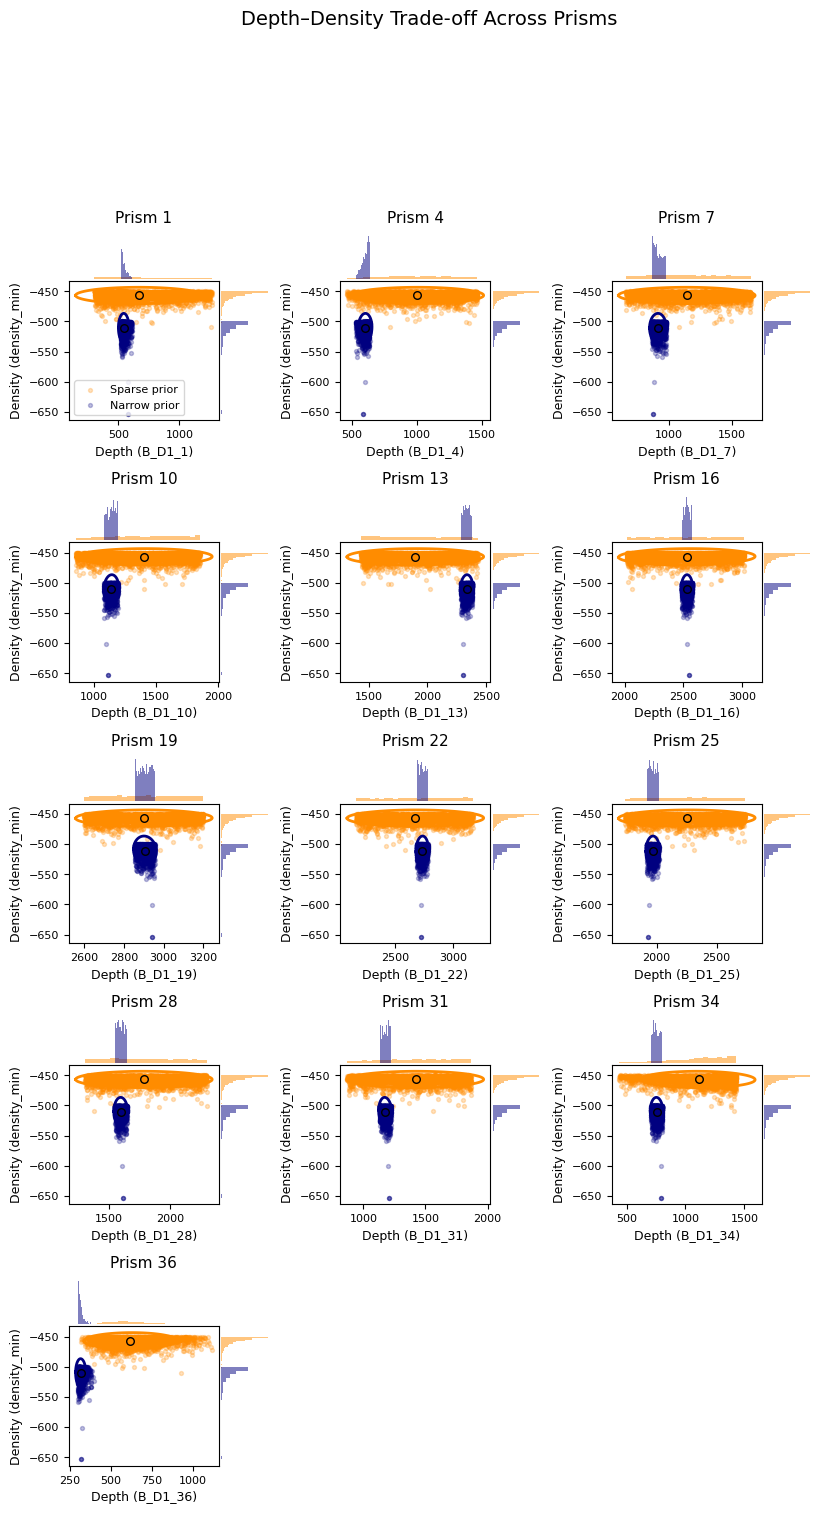

In [ ]:
# ============================================================
# USER-EDITABLE SECTION
# ============================================================
samples_sparse = samples2
samples_narrow = samples1_new2
prism_indices  = [1,4,7,10,13,16,19,22,25,28,31,34,36]   # <-- any set of prisms you want side by side
n_std          = 2.0

# Extract arrays for the sanity check
check_sparse = np.array(samples_sparse["B_D1_5"])
check_narrow = np.array(samples_narrow["B_D1_5"])

# Sanity check before plotting
# If the shapes are different, they are definitely not identical.
# If they are the same shape, check if the values are identical.
assert (check_sparse.shape != check_narrow.shape) or not np.allclose(
    check_sparse, check_narrow
), "samples1 and samples2 look identical — check the MCMC extraction cells above."

fig, axes = plot_2d_comparison_multi(samples_sparse, samples_narrow, prism_indices, n_std=n_std)



In [ ]:
rmse_narrow = float(jnp.sqrt(jnp.mean((pred_mean - g) ** 2)))
rmse_sparse = float(jnp.sqrt(jnp.mean((pred_mean2 - g) ** 2)))

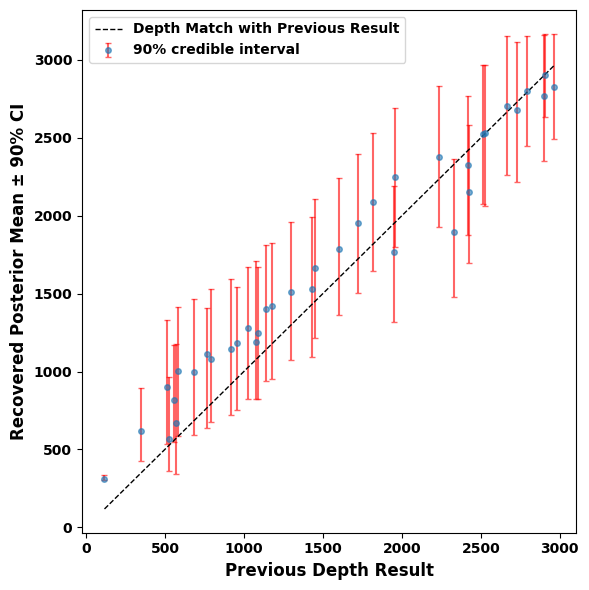

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# substitute your actual synthetic "true" arrays here (length n)
true_B_D2 = z_prev
#true_B_D2 = bd2

rec_B_D2    = np.array([samples2[f"B_D1_{i+1}"].mean() for i in range(n)])
rec_B_D2_lo = np.array([np.percentile(samples2[f"B_D1_{i+1}"], 5)  for i in range(n)])
rec_B_D2_hi = np.array([np.percentile(samples2[f"B_D1_{i+1}"], 95) for i in range(n)])

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(true_B_D2, rec_B_D2,

            yerr=[rec_B_D2 - rec_B_D2_lo, rec_B_D2_hi - rec_B_D2],
            fmt="o", ms=4, alpha=0.6, ecolor="red", capsize=2,label="90% credible interval")
lims = [min(true_B_D2.min(), rec_B_D2.min()), max(true_B_D2.max(), rec_B_D2.max())]
ax.plot(lims, lims, "k--", lw=1, label="Depth Match with Previous Result")
ax.set_xlabel("Previous Depth Result", fontsize=12, weight='bold')
ax.set_ylabel("Recovered Posterior Mean ± 90% CI", fontsize=12, weight='bold')
#ax.set_title("Per-prism recovery: layer 1 bottom depth")
plt.setp(ax.get_yticklabels(), visible= True,weight='bold')
plt.setp(ax.get_xticklabels(), visible= True,weight='bold')
ax.legend(fontsize=8, prop={'weight':'bold'}); plt.tight_layout(); plt.show()

In [ ]:
bd1

array([ 668.37401808,  544.28350987,  893.29024708,  986.48617462,
        988.96313505, 1084.18080478, 1147.36780182, 1285.82532345,
       1182.30033622, 1399.32643341, 1534.66282312, 1765.02926001,
       1889.42091431, 2147.03171083, 2322.82968349, 2521.11643477,
       2699.47768769, 2804.23435722, 2903.58944764, 2820.15279246,
       2755.18962657, 2678.27394707, 2511.36423479, 2371.88233887,
       2237.91907958, 2082.97647437, 1942.51187824, 1780.52940093,
       1659.90927016, 1504.51172845, 1413.89259761, 1235.05979374,
       1182.85524127, 1113.98461809,  822.20790781,  624.34744108,
        310.52021287])

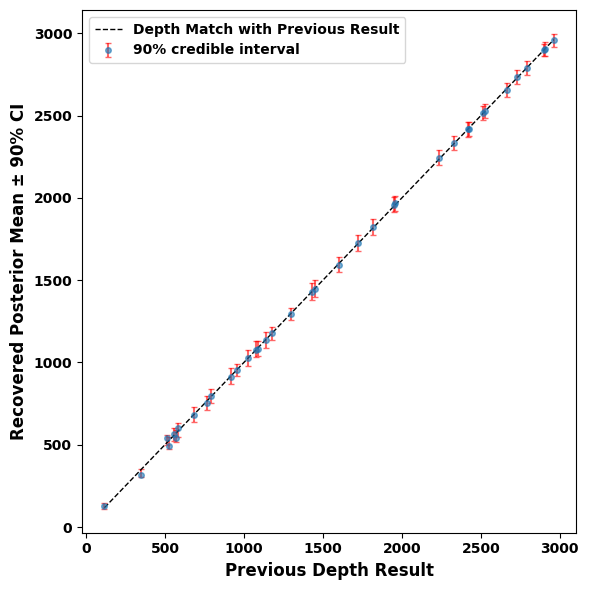

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# substitute your actual synthetic "true" arrays here (length n)
true_B_D2 =z_prev
#true_B_D2 = bd2

rec_B_D2    = np.array([samples1_new2[f"B_D1_{i+1}"].mean() for i in range(n)])
rec_B_D2_lo = np.array([np.percentile(samples1_new2[f"B_D1_{i+1}"], 5)  for i in range(n)])
rec_B_D2_hi = np.array([np.percentile(samples1_new2[f"B_D1_{i+1}"], 95) for i in range(n)])

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(true_B_D2, rec_B_D2,
            yerr=[rec_B_D2 - rec_B_D2_lo, rec_B_D2_hi - rec_B_D2],
            fmt="o", ms=4, alpha=0.6, ecolor="red", capsize=2,label="90% credible interval")
lims = [min(true_B_D2.min(), rec_B_D2.min()), max(true_B_D2.max(), rec_B_D2.max())]
ax.plot(lims, lims, "k--", lw=1, label="Depth Match with Previous Result")
ax.set_xlabel("Previous Depth Result", fontsize=12, weight='bold')
ax.set_ylabel("Recovered Posterior Mean ± 90% CI", fontsize=12, weight='bold')
#ax.set_title("Per-prism recovery: layer 1 bottom depth")
plt.setp(ax.get_yticklabels(), visible= True,weight='bold')
plt.setp(ax.get_xticklabels(), visible= True,weight='bold')
ax.legend(fontsize=8, prop={'weight':'bold'}); plt.tight_layout(); plt.show()

Text(0.5, 1.0, 'Signed depth deviation under widened prior')

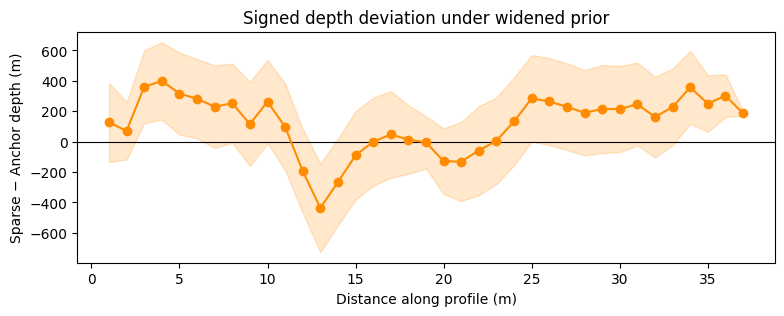

In [ ]:
prism_centers_x=np.arange(1,n+1,1)
depth_diff = inverted_depths_sparse - inverted_depths_narrow   # or anchor_means, same thing here
plt.figure(figsize=(9, 3))
plt.axhline(0, color='k', lw=0.8)
plt.plot(prism_centers_x, depth_diff, 'o-', color='darkorange')
plt.fill_between(prism_centers_x, depth_diff - np.array([params8[f"B_D1_{i+1}"].std() for i in range(n)]), depth_diff + np.array([params8[f"B_D1_{i+1}"].std() for i in range(n)]),
                  alpha=0.2, color='darkorange')
plt.xlabel('Distance along profile (m)')
plt.ylabel('Sparse − Anchor depth (m)')
#plt.ylim(-200,200)
plt.title('Signed depth deviation under widened prior')

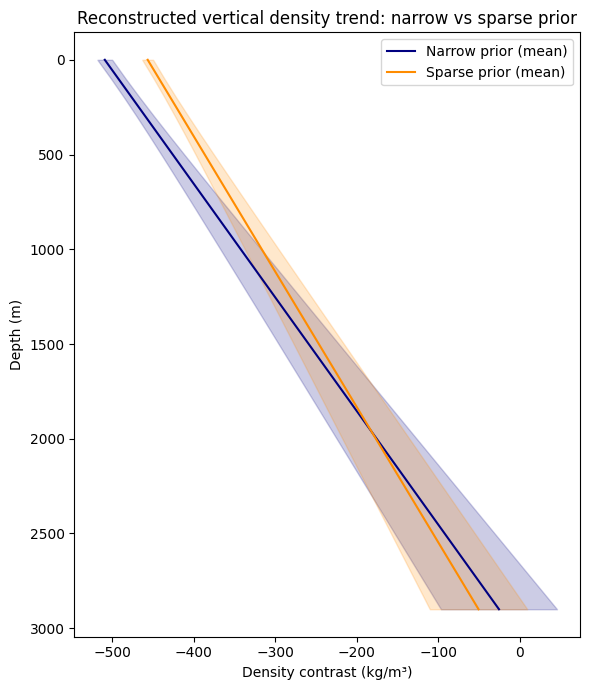

In [ ]:
def density_profile(samples, n_draws=200, max_depth=3000, dz=100, seed=0):
    """
    Draws n_draws posterior samples of (density_min, density_gradient)
    and reconstructs rho(z) = density_min + density_gradient * k,
    with k = z / dz — matching the layer-index convention used in
    Cal_vertical_3 / Cal_vertical_3_posterior_predictive (100 m layers).

    Returns z (depth axis), posterior mean of rho(z), posterior std of rho(z).
    """
    rng = np.random.default_rng(seed)
    dg_all = np.asarray(samples["density_gradient"])
    dm_all = np.asarray(samples["density_min"])
    n_total = dg_all.shape[0]
    idx = rng.choice(n_total, size=min(n_draws, n_total), replace=False)

    z = np.arange(0, max_depth, dz)
    k = z / dz

    profiles = np.array([dm_all[s] + dg_all[s] * k for s in idx])  # (n_draws, len(z))
    return z, profiles.mean(axis=0), profiles.std(axis=0)


z, mean_narrow, std_narrow = density_profile(samples_narrow)
_, mean_sparse, std_sparse = density_profile(samples_sparse)

plt.figure(figsize=(6, 7))
plt.plot(mean_narrow, z, color='navy', label='Narrow prior (mean)')
plt.fill_betweenx(z, mean_narrow - std_narrow, mean_narrow + std_narrow,
                   color='navy', alpha=0.2)
plt.plot(mean_sparse, z, color='darkorange', label='Sparse prior (mean)')
plt.fill_betweenx(z, mean_sparse - std_sparse, mean_sparse + std_sparse,
                   color='darkorange', alpha=0.2)
plt.gca().invert_yaxis()
plt.xlabel('Density contrast (kg/m³)')
plt.ylabel('Depth (m)')
plt.title('Reconstructed vertical density trend: narrow vs sparse prior')
plt.legend()
plt.tight_layout()
#plt.savefig('density_profile_comparison.png', dpi=200)
plt.show()